In [1]:
from langgraph.graph import StateGraph, START, END
from spm_agent.states.pfm_experiment_state import PFMExperimentState

from spm_agent.nodes.preflight_node import preflight_node
from spm_agent.nodes.sync_status_node import sync_status_node
from spm_agent.nodes.scanner_calibration_node import get_scanner_calibrations_node
from spm_agent.nodes.decision_node import experiment_decision_node
from spm_agent.nodes.scan_plan_node import scan_plan_node
from spm_agent.nodes.scan_run_node import scan_run_node
from spm_agent.nodes.full_exp_analysis_node import full_exp_analysis_node
from spm_agent.nodes.loop_pick_point_node import loop_pick_point_node
from spm_agent.nodes.loop_plan_node import loop_plan_node
from spm_agent.nodes.move_tip_node import move_tip_node
from spm_agent.nodes.loop_run_node import loop_run_node
from spm_agent.nodes.relocate_frame_node import relocate_frame_node
from spm_agent.nodes.summary_node import summary_node

In [2]:
def route_by_decision(state):
    return state["decision_records"][-1].action

def route_by_action(state: PFMExperimentState) -> str:
    """First branch: which kind of measurement the decision ordered."""
    return state["decision_records"][-1].action


def route_by_frame_action(state: PFMExperimentState) -> str:
    """Second branch, scan only: whether the frame moves before it is planned."""
    return "relocate" if state["decision_records"][-1].frame_action == "relocate" else "keep"


async def scan_branch_node(state: PFMExperimentState) -> PFMExperimentState:
    """Entry of the scan branch, and the junction the frame_action test hangs off.
    Changes nothing: it guards the branch's precondition and states the framing
    before either path runs."""
    pending = state["pending"]
    if pending["kind"] != "scan":                                    # type: ignore
        raise RuntimeError(
            f"scan_branch called for kind={pending['kind']!r}")      # type: ignore

    decision = state["decision_records"][-1]
    print(f"[scan_branch] frame_action={decision.frame_action}")
    return {}

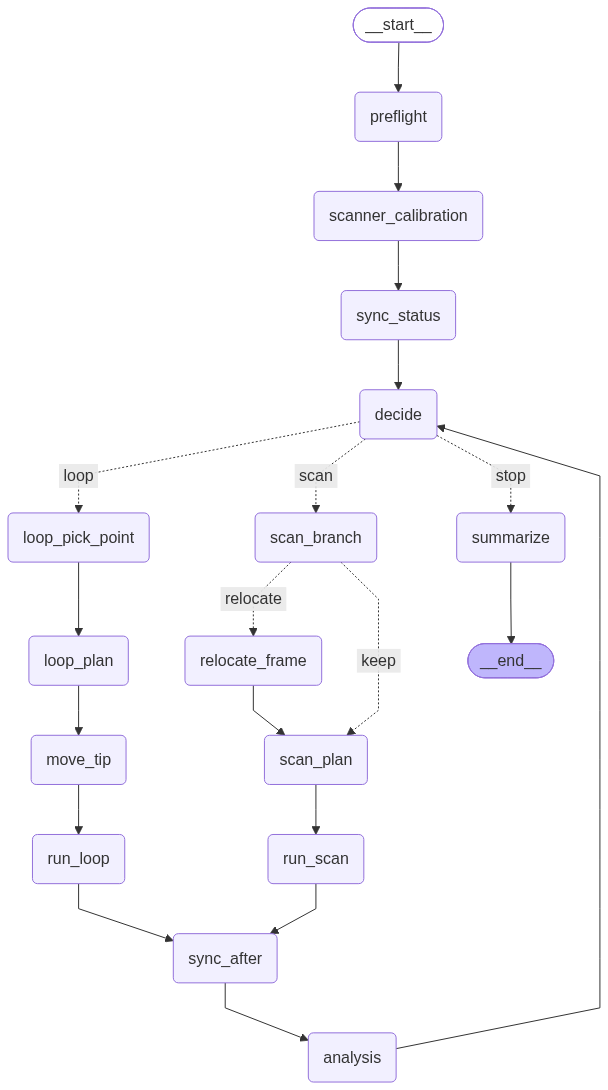

In [3]:
g = StateGraph(PFMExperimentState)
g.add_node("preflight", preflight_node)
g.add_node("scanner_calibration", get_scanner_calibrations_node)
g.add_node("sync_status", sync_status_node)
g.add_node("decide", experiment_decision_node)

g.add_node("scan_branch",    scan_branch_node)
g.add_node("relocate_frame", relocate_frame_node)
g.add_node("scan_plan", scan_plan_node)
g.add_node("run_scan",    scan_run_node)
g.add_node("sync_after",  sync_status_node)     # same fn, second node name
g.add_node("analysis",    full_exp_analysis_node)

g.add_node("loop_pick_point", loop_pick_point_node)
g.add_node("loop_plan",  loop_plan_node)
g.add_node("move_tip",   move_tip_node)
g.add_node("run_loop",   loop_run_node)

g.add_node("summarize", summary_node)



g.add_edge(START, "preflight")
g.add_edge("preflight", "scanner_calibration")
g.add_edge("scanner_calibration", "sync_status")
g.add_edge("sync_status", "decide")

g.add_conditional_edges("decide", route_by_action,
                        {"scan": "scan_branch", "loop": "loop_pick_point", "stop": "summarize"})

g.add_conditional_edges("scan_branch", route_by_frame_action,
                        {"relocate": "relocate_frame", "keep": "scan_plan"})

g.add_edge("relocate_frame", "scan_plan")
g.add_edge("scan_plan", "run_scan")
g.add_edge("run_scan", "sync_after")
g.add_edge("sync_after", "analysis")
g.add_edge("analysis", "decide")

g.add_edge("loop_pick_point", "loop_plan")
g.add_edge("loop_plan",  "move_tip")
g.add_edge("move_tip",   "run_loop")
g.add_edge("run_loop",   "sync_after")

g.add_edge("summarize", END)

fin_gr = g.compile()
fin_gr

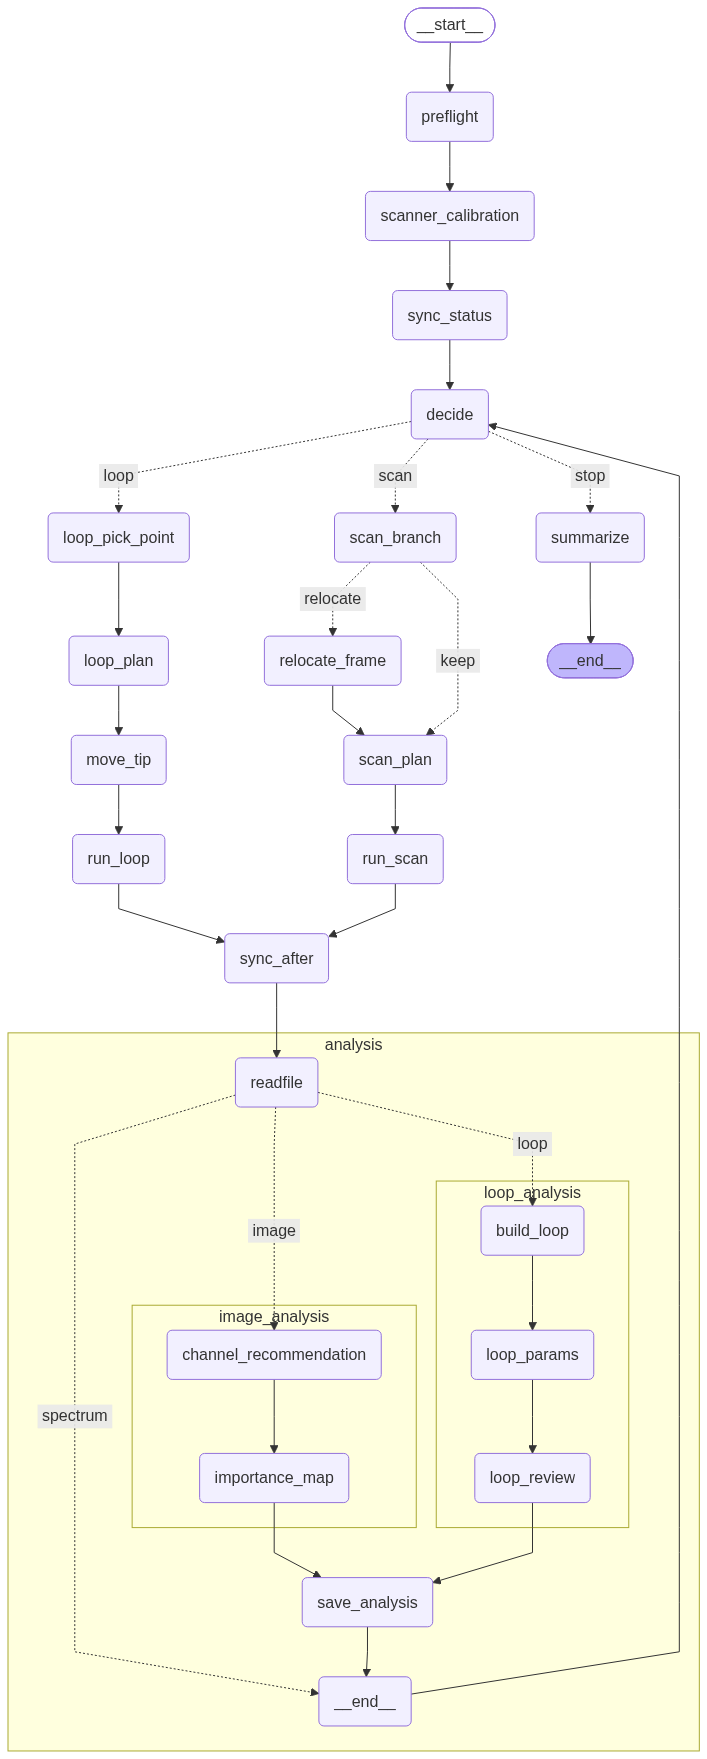

In [4]:
from IPython.display import Image
Image(fin_gr.get_graph(xray=True).draw_mermaid_png())

In [5]:
from spm_agent.config import new_run

EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    # "Compare switching inside domains vs near domain walls",
    # "Study wall-mediated switching"
    # "Investigate the role of domain walls in polarization switching",
    # "Characterize the spatial heterogeneity of switching behavior",
    # "Identify the microstructural origins of switching asymmetry",
    # "Determine the most informative locations for testing competing switching mechanisms",
    # "Investigate how local domain configuration influences polarization switching behavior."
    "Determine how local domain structure affects polarization switching dynamics.",

]

EXPERIMENT_CONTEXT = (
        "This is Dual AC Resonance Tracking (DART) PFM experiment: two drive frequencies f1 and f2 straddle the "
        "contact resonance.  "
        "The sample is lead lanthanum zirconate titanate relazor ferroelectric exhibiting complex domain structures "
        "and heterogeneous polarization-switching behavior."
)

In [9]:
print(new_run("plzt_domain_structure_affect_11")) 

res = await fin_gr.ainvoke(
    {"experiment_tasks": EXPERIMENT_TASKS, "experiment_context": EXPERIMENT_CONTEXT})

C:\Users\Asylum User\Documents\GitHub\SPM_agent_simple\src\runs\20260823_235215_plzt_domain_structure_affect_11
[preflight] dir 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260822' | frame 2.0 um @ 256 px | f_DART 373.1 kHz | V_ac 0.5 V | feedback False
[scan_branch] frame_action=hold
[scan_plan] first scan — operator settings adopted
[run_scan] starting — 2.00 um @ 256 px, 0.801 Hz (~319 s); args=instrument defaults
[run_scan] done — tuned=True -> C:\Users\Asylum User\Documents\Asylum Research Data\260822\PZT_loop_test_0051.ibw
[pick] phase_heterogeneity/max -> px(8,247) | phi 0.8275, safety 0.8161 | previously []
[loop_plan] first loop — operator waveform adopted (v_dc_max 6.00 V, 2 cycles)
[move_tip] px(8,247) -> (+0.9336, +0.9336) um on a 2.00 um frame (7.8 nm/px)
[move_tip] achieved (+0.9336, +0.9336) um, error 0.0 nm, feedback on
[run_loop] starting — v_dc_max 6.00 V, 0.500 Hz, 2 cycles, pulse 30.0 ms (~4 s); changes=none
[run_loop] payload keys: ['loop_frequency', '

In [10]:
from spm_agent.mcp.spm_session import call

print(await call("pfm_get_experiment_status"))                       # centre before
print(await call("pfm_set_scan_center", {"x_offset_m": -1e-6, "y_offset_m": 0.0}))
print(await call("pfm_get_experiment_status"))                       # centre after

{'scan_size_m': 1.5e-05, 'n_points': 256, 'scan_rate_hz': 0.80128205, 'x_scan_center_m': 0.0, 'y_scan_center_m': 0.0, 'v_ac_v': 0.30000001, 'v_dc_surface_v': 0.0, 'v_dc_tip_v': 0.0, 'f_dart_hz': 369796.0, 'f_dart_width_hz': 10000.0, 'dart_igain': 500.0, 'setpoint_defl_v': -0.40000001, 'igain': 50.0, 'feedback_on': False, 'x_lvdt_sens_m_per_v': 9.2639584e-06, 'y_lvdt_sens_m_per_v': 9.9031586e-06, 'stage_x_m': -0.0033435938, 'stage_y_m': 0.0037518749, 'v_dc_max': 8.0, 'loop_frequency': 0.5, 'var0_loop_phase': 0.0, 'var1_pulsetime_s': 0.029999999, 'n_cycles': 2, 'x_probe_lvdt_m': -2.450528307691104e-05, 'y_probe_lvdt_m': 1.64561628224681e-05, 'directory': 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260822', 'ts_unix': 1787492701.517468, 'warnings': [], 'message': 'Instrument status read successfully.'}
{'x_offset_m': -1e-06, 'y_offset_m': 0.0, 'scan_size_m': 1.5e-05, 'warnings': [], 'message': 'Scan center set to (-1.00 um, 0.00 um).'}
{'scan_size_m': 1.5e-05, 'n_points': 25

In [8]:
res

NameError: name 'res' is not defined

In [10]:
from spm_agent.mcp.spm_session import call
from spm_agent.utils.pick_utils import pixel_to_frame_xy

async def lvdt():
    s = await call("pfm_get_experiment_status")
    return s["x_probe_lvdt_m"], s["y_probe_lvdt_m"], s["feedback_on"]

print("before      :", [f"{v*1e6:+.4f}" for v in (await lvdt())[:2]])

x, y = pixel_to_frame_xy(ss, 40, 40, True)          # ss from the scan frame
d = await call("pfm_move_tip", {"x_m": x, "y_m": y})
print("payload keys:", sorted(d))                    # does it even report x_error_m?
print("after move  :", [f"{v*1e6:+.4f}" for v in (await lvdt())[:2]])

await call("pfm_measure_hysteresis_loop",
           {"v_dc_max": 5.0, "loop_frequency": 0.3, "var0_loop_phase": 0.0,
            "var1_pulsetime_s": 0.05, "n_cycles": 2})
print("after loop  :", [f"{v*1e6:+.4f}" for v in (await lvdt())[:2]])

  + Exception Group Traceback (most recent call last):
  |   File "c:\Users\Asylum User\Documents\GitHub\SPM_agent_simple\.venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3746, in run_code
  |     await eval(code_obj, self.user_global_ns, self.user_ns)
  |   File "C:\Users\Asylum User\AppData\Local\Temp\ipykernel_29464\3866079495.py", line 8, in <module>
  |     print("before      :", [f"{v*1e6:+.4f}" for v in (await lvdt())[:2]])
  |                                                       ^^^^^^^^^^^^
  |   File "C:\Users\Asylum User\AppData\Local\Temp\ipykernel_29464\3866079495.py", line 5, in lvdt
  |     s = await call("pfm_get_experiment_status")
  |         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  |   File "C:\Users\Asylum User\Documents\GitHub\SPM_agent_simple\src\spm_agent\mcp\spm_session.py", line 42, in call
  |     return unwrap(await spm().call_tool(tool, args), tool)
  |                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  |   File "C:\Users\Asylum User\Docu